# U-Net Droplet / Nucleus Training Notebook — v6.3

### Changes from v6.2
| # | Change | Why |
|---|--------|-----|
| 1 | **Weighted CE + weighted Dice loss** | Class 2 (nucleus) was under-represented in the gradient signal; background and droplet dominate pixel counts even with nucleus-anchored sampling |
| 2 | **SpatialDropout2D** at bottleneck (0.5) and two deepest decoder blocks (0.3) | 5 k patches from one hyperstack = low diversity; Dropout forces generalization |
| 3 | **`seed` field added to `TrainingConfig`** | `cfg.seed` AttributeError would crash patch generation |
| 4 | **Timepoint-stratified validation split** | Random 80/20 split allowed train/val patches from the same T/Z plane, inflating val metrics |

Everything else is unchanged from v6.2.


In [1]:
# ============================================================
# 1. Core imports
# ============================================================

from dataclasses import dataclass, field
from pathlib import Path
import os
import math
import time
import gc
import shutil
import inspect

import numpy as np
import pandas as pd

import tifffile as tiff
import matplotlib.pyplot as plt

from scipy import ndimage as ndi
from skimage import filters, morphology, measure
from skimage.filters import threshold_local
from skimage.measure import regionprops

import tensorflow as tf
from tensorflow.keras import layers, models

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices("GPU")))


2026-05-06 13:56:53.430506: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-06 13:56:53.430573: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-06 13:56:53.431756: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-06 13:56:53.439329: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-06 13:56:55.156467: W tensorflow/compiler/tf2

TensorFlow: 2.15.1
Num GPUs Available: 1


In [2]:
# ============================================================
# 2. Configuration
# ============================================================

@dataclass
class TrainingConfig:
    # ----------------------------
    # Project paths
    # ----------------------------
    data_root: Path = Path("/home/tdeibert/Data/Machine_Learning_Dev/")
    model_root: Path = None          # set in __post_init__
    image_root: Path = None
    out_root:   Path = None

    image_filename: str = "control_extract_1.1.tif"

    # ----------------------------
    # Image metadata  (T, Z, C, Y, X)
    # ----------------------------
    pixel_size_um: float = 0.108
    n_channels:    int   = 3

    membrane_channel_idx: int = 0
    nucleus_channel_idx:  int = 1
    npc_channel_idx:      int = 2

    # ----------------------------
    # Focus filtering
    # ----------------------------
    use_focus_filter:      bool  = True
    min_focus_score:       float = 0.0005
    exclude_edge_z_planes: bool  = True
    edge_z_exclusion:      int   = 2

    # ----------------------------
    # NPC / droplet segmentation
    # ----------------------------
    use_data_driven_tail:    bool  = True
    histogram_bins:          int   = 512
    histogram_smooth_window: int   = 9
    tail_start_quantile:     float = 0.80
    min_clip_quantile:       float = 0.95
    max_clip_quantile:       float = 0.995
    puncta_clip_quantile:    float = 0.985

    droplet_blur_sigma:        float = 8.0
    droplet_local_block_size:  int   = 101
    droplet_local_offset:      float = -0.02
    min_droplet_area_um2:      float = 500.0
    droplet_hole_area_um2:     float = 8000.0
    droplet_closing_radius_um: float = 2.0

    # ----------------------------
    # Nucleus segmentation
    # ----------------------------
    min_nucleus_area_um2:      float = 80.0
    max_nucleus_area_um2:      float = 1500.0
    nucleus_blur_sigma:        float = 1.5
    nucleus_threshold_method:  str   = "otsu"
    nucleus_closing_radius_um: float = 1.5
    nucleus_hole_area_um2:     float = 200.0

    # ----------------------------
    # Patch extraction
    # ----------------------------
    patch_size:                  int   = 512
    patch_jitter_px:             int   = 128
    patches_per_plane:           int   = 24
    nucleus_patch_fraction:      float = 0.70
    droplet_patch_fraction:      float = 0.20
    hard_negative_patch_fraction: float = 0.10
    min_label_fraction:          float = 0.005

    # ----------------------------
    # Model / training
    # ----------------------------
    model_name:          str   = "unet_droplet_nucleus_v3.0"
    num_classes:         int   = 3
    batch_size:          int   = 2
    epochs:              int   = 50
    learning_rate:       float = 1e-4
    validation_fraction: float = 0.20

    # FIX 3: seed now lives in the dataclass (was only a module-level constant)
    seed: int = 42

    # ----------------------------
    # v6.3: loss class weights  [bg, droplet, nucleus]
    # ----------------------------
    loss_class_weights: tuple = (0.5, 1.0, 4.0)

    # ----------------------------
    # v6.3: validation held-out timepoints
    # None → hold out the last timepoint automatically
    # ----------------------------
    val_timepoints: object = None   # e.g. [9] or None

    def __post_init__(self):
        if self.model_root is None:
            self.model_root = self.data_root / "Models"
        if self.image_root is None:
            self.image_root = self.data_root / "Images"
        if self.out_root is None:
            self.out_root = self.data_root / "Outputs"

    @property
    def image_file(self):
        return self.image_root / self.image_filename

    @property
    def training_root(self):
        return self.out_root / f"training_patches_{self.model_name}"

    @property
    def image_patch_dir(self):
        return self.training_root / "images"

    @property
    def label_patch_dir(self):
        return self.training_root / "labels"

    @property
    def qc_dir(self):
        return self.out_root / f"qc_{self.model_name}"

    @property
    def best_model_path(self):
        return self.model_root / f"{self.model_name}_best.keras"

    @property
    def final_model_path(self):
        return self.model_root / f"{self.model_name}_final.keras"


cfg = TrainingConfig()

for p in [
    cfg.data_root, cfg.model_root, cfg.image_root, cfg.out_root,
    cfg.training_root, cfg.image_patch_dir, cfg.label_patch_dir, cfg.qc_dir,
]:
    p.mkdir(parents=True, exist_ok=True)

# Backward-compatible module-level aliases
DATA_ROOT    = cfg.data_root
MODEL_ROOT   = cfg.model_root
IMAGE_ROOT   = cfg.image_root
OUT_ROOT     = cfg.out_root
IMAGE_FILE   = cfg.image_file
PIXEL_SIZE_UM = cfg.pixel_size_um
MEM_CH       = cfg.membrane_channel_idx
NUC_CH       = cfg.nucleus_channel_idx
NPC_CH       = cfg.npc_channel_idx
PATCH_SIZE   = cfg.patch_size
NUM_CHANNELS = cfg.n_channels
NUM_CLASSES  = cfg.num_classes
BATCH_SIZE   = cfg.batch_size

print("DATA_ROOT       :", DATA_ROOT)
print("IMAGE_FILE      :", IMAGE_FILE)
print("MODEL_ROOT      :", MODEL_ROOT)
print("OUT_ROOT        :", OUT_ROOT)
print("PATCH_SIZE      :", PATCH_SIZE)
print("Patch FOV       :", PATCH_SIZE * PIXEL_SIZE_UM, "µm")
print("BEST_MODEL_PATH :", cfg.best_model_path)
print("FINAL_MODEL_PATH:", cfg.final_model_path)
print("seed in cfg     :", cfg.seed)  # confirms FIX 3


DATA_ROOT       : /home/tdeibert/Data/Machine_Learning_Dev
IMAGE_FILE      : /home/tdeibert/Data/Machine_Learning_Dev/Images/control_extract_1.1.tif
MODEL_ROOT      : /home/tdeibert/Data/Machine_Learning_Dev/Models
OUT_ROOT        : /home/tdeibert/Data/Machine_Learning_Dev/Outputs
PATCH_SIZE      : 512
Patch FOV       : 55.296 µm
BEST_MODEL_PATH : /home/tdeibert/Data/Machine_Learning_Dev/Models/unet_droplet_nucleus_v3.0_best.keras
FINAL_MODEL_PATH: /home/tdeibert/Data/Machine_Learning_Dev/Models/unet_droplet_nucleus_v3.0_final.keras
seed in cfg     : 42


In [3]:
# ============================================================
# 3. Memory-mapped TIFF loading
# ============================================================

def load_memmap_tiff(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Could not find TIFF file: {path}")
    arr = tiff.memmap(str(path))
    print("Loaded memory-mapped TIFF")
    print("  Path :", path)
    print("  Shape:", arr.shape)
    print("  Dtype:", arr.dtype)
    return arr

img_fov = load_memmap_tiff(IMAGE_FILE)
img = img_fov

if img_fov.ndim != 5:
    raise ValueError(f"Expected shape (T, Z, C, Y, X), got {img_fov.shape}")

print("Image shape:", img_fov.shape)
print("Image dtype:", img_fov.dtype)


Loaded memory-mapped TIFF
  Path : /home/tdeibert/Data/Machine_Learning_Dev/Images/control_extract_1.1.tif
  Shape: (10, 20, 3, 3889, 5732)
  Dtype: >u2
Image shape: (10, 20, 3, 3889, 5732)
Image dtype: >u2


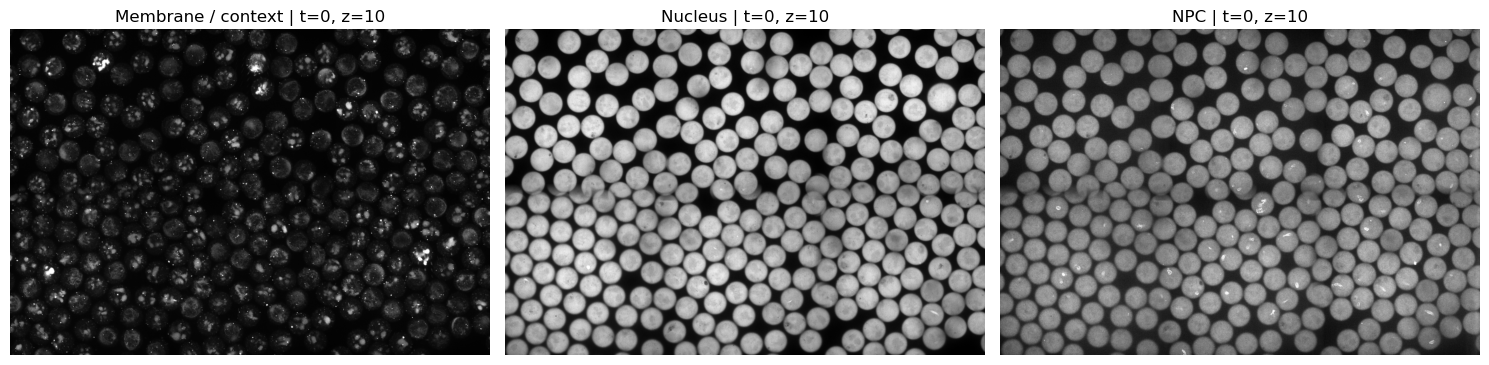

In [4]:
# ============================================================
# 4. Simple viewer: one timepoint, one Z plane, all channels
# ============================================================

def show_plane_all_channels(img, t=0, z=0, channel_names=None, percentile=(1, 99.8)):
    plane = img[t, z]   # (C, Y, X)
    C = plane.shape[0]
    if channel_names is None:
        channel_names = [f"Channel {i}" for i in range(C)]
    fig, axes = plt.subplots(1, C, figsize=(5 * C, 5))
    if C == 1:
        axes = [axes]
    for c in range(C):
        arr = np.asarray(plane[c])
        lo, hi = np.percentile(arr, percentile)
        axes[c].imshow(arr, cmap="gray", vmin=lo, vmax=hi)
        axes[c].set_title(f"{channel_names[c]} | t={t}, z={z}")
        axes[c].axis("off")
    plt.tight_layout()
    plt.show()

show_plane_all_channels(
    img_fov, t=0,
    z=min(10, img_fov.shape[1] - 1),
    channel_names=["Membrane / context", "Nucleus", "NPC"],
)


In [5]:
# ============================================================
# 5. Segmentation utilities: units, normalization, focus
# ============================================================

def area_um2_to_px(area_um2, pixel_size_um=PIXEL_SIZE_UM):
    if area_um2 is None:
        return None
    return int(np.ceil(area_um2 / (pixel_size_um ** 2)))

def radius_um_to_px(radius_um, pixel_size_um=PIXEL_SIZE_UM):
    if radius_um is None:
        return 0
    return max(1, int(np.ceil(radius_um / pixel_size_um)))

def normalize_01(img2d):
    arr = img2d.astype("float32", copy=False)
    lo, hi = np.nanmin(arr), np.nanmax(arr)
    if hi <= lo:
        return np.zeros_like(arr, dtype="float32")
    return (arr - lo) / (hi - lo)

def normalize_channel(ch2d):
    return normalize_01(ch2d).astype("float32")

def focus_score_variance_laplacian(img2d):
    img_f = normalize_01(img2d)
    lap = ndi.laplace(img_f)
    return float(np.var(lap))

def z_plane_allowed(z, n_z, exclude_edge_z=cfg.edge_z_exclusion):
    if exclude_edge_z is None or exclude_edge_z <= 0:
        return True
    return exclude_edge_z <= z < (n_z - exclude_edge_z)

def plane_passes_focus(nuc2d, min_focus_score=cfg.min_focus_score):
    score = focus_score_variance_laplacian(nuc2d)
    return score >= min_focus_score, score

def filter_objects_by_area(mask, pixel_size_um, min_area_um2=None, max_area_um2=None):
    labeled = measure.label(mask)
    clean = np.zeros_like(mask, dtype=bool)
    min_px = 0 if min_area_um2 is None else area_um2_to_px(min_area_um2, pixel_size_um)
    max_px = np.inf if max_area_um2 is None else area_um2_to_px(max_area_um2, pixel_size_um)
    for region in measure.regionprops(labeled):
        if min_px <= region.area <= max_px:
            clean[labeled == region.label] = True
    return clean

print("50 µm² nucleus minimum =", area_um2_to_px(50, PIXEL_SIZE_UM), "px")
print("512 px patch FOV =", PATCH_SIZE * PIXEL_SIZE_UM, "µm")


50 µm² nucleus minimum = 4287 px
512 px patch FOV = 55.296 µm


In [6]:
# ============================================================
# 6. Data-driven NPC puncta clipping
# ============================================================

def estimate_npc_histogram_tail_cutoff(
    npc2d,
    bins=cfg.histogram_bins,
    smooth_window=cfg.histogram_smooth_window,
    tail_start_quantile=cfg.tail_start_quantile,
    min_clip_quantile=cfg.min_clip_quantile,
    max_clip_quantile=cfg.max_clip_quantile,
):
    npc_f = normalize_01(npc2d)
    vals = npc_f[np.isfinite(npc_f)].ravel()
    vals = vals[vals > 0]

    if vals.size == 0:
        return 1.0, 1.0, {"reason": "empty_nonzero_values", "cutoff_value": 1.0, "cutoff_quantile": 1.0}

    hist, edges = np.histogram(vals, bins=bins, range=(0, 1))
    centers = (edges[:-1] + edges[1:]) / 2

    smooth_window = int(max(3, smooth_window))
    if smooth_window % 2 == 0:
        smooth_window += 1
    kernel = np.ones(smooth_window, dtype="float32") / smooth_window
    hist_smooth = np.convolve(hist.astype("float32"), kernel, mode="same")
    log_hist = np.log1p(hist_smooth)
    slope = np.gradient(log_hist, centers)

    tail_start = np.quantile(vals, tail_start_quantile)
    tail_mask = centers >= tail_start

    if tail_mask.sum() < smooth_window:
        cutoff_quantile = max_clip_quantile
        cutoff_value = float(np.quantile(vals, cutoff_quantile))
        reason = "fallback_insufficient_tail_bins"
    else:
        tail_centers = centers[tail_mask]
        tail_slope = slope[tail_mask]
        slope_smooth = np.convolve(tail_slope, kernel, mode="same")
        tail_idx = int(np.argmin(slope_smooth))
        raw_cutoff_value = float(tail_centers[tail_idx])
        raw_cutoff_quantile = float(np.mean(vals <= raw_cutoff_value))
        cutoff_quantile = float(np.clip(raw_cutoff_quantile, min_clip_quantile, max_clip_quantile))
        cutoff_value = float(np.quantile(vals, cutoff_quantile))
        reason = "sliding_window_histogram_tail"

    debug = {
        "hist": hist, "hist_smooth": hist_smooth, "centers": centers, "slope": slope,
        "tail_start": float(tail_start), "cutoff_value": float(cutoff_value),
        "cutoff_quantile": float(cutoff_quantile), "reason": reason,
    }
    return cutoff_value, cutoff_quantile, debug


def clip_npc_puncta_data_driven(
    npc2d,
    bins=cfg.histogram_bins,
    smooth_window=cfg.histogram_smooth_window,
    tail_start_quantile=cfg.tail_start_quantile,
    min_clip_quantile=cfg.min_clip_quantile,
    max_clip_quantile=cfg.max_clip_quantile,
):
    npc_f = normalize_01(npc2d)
    cutoff_value, cutoff_quantile, debug = estimate_npc_histogram_tail_cutoff(
        npc_f, bins=bins, smooth_window=smooth_window,
        tail_start_quantile=tail_start_quantile,
        min_clip_quantile=min_clip_quantile, max_clip_quantile=max_clip_quantile,
    )
    npc_clean = npc_f.copy()
    npc_clean[npc_clean > cutoff_value] = cutoff_value
    npc_clean = normalize_01(npc_clean)
    return npc_clean, cutoff_value, cutoff_quantile, debug


In [7]:
# ============================================================
# 7. Clean segmentation functions
# ============================================================

def segment_droplet_from_npc(
    npc2d, pixel_size_um=PIXEL_SIZE_UM,
    use_data_driven_tail=cfg.use_data_driven_tail,
    puncta_clip_quantile=cfg.puncta_clip_quantile,
    histogram_bins=cfg.histogram_bins,
    histogram_smooth_window=cfg.histogram_smooth_window,
    tail_start_quantile=cfg.tail_start_quantile,
    min_clip_quantile=cfg.min_clip_quantile,
    max_clip_quantile=cfg.max_clip_quantile,
    blur_sigma=cfg.droplet_blur_sigma,
    local_block_size=cfg.droplet_local_block_size,
    local_offset=cfg.droplet_local_offset,
    min_droplet_area_um2=cfg.min_droplet_area_um2,
    hole_area_um2=cfg.droplet_hole_area_um2,
    closing_radius_um=cfg.droplet_closing_radius_um,
    max_droplet_area_um2=None, erosion_radius_um=None,
    return_debug=False, **unused_kwargs,
):
    npc_f = normalize_01(npc2d)

    if use_data_driven_tail:
        npc_clean, clip_value, clip_quantile, puncta_debug = clip_npc_puncta_data_driven(
            npc2d, bins=histogram_bins, smooth_window=histogram_smooth_window,
            tail_start_quantile=tail_start_quantile,
            min_clip_quantile=min_clip_quantile, max_clip_quantile=max_clip_quantile,
        )
        clip_method = "data_driven_histogram_tail"
    else:
        clip_value = float(np.quantile(npc_f, puncta_clip_quantile))
        clip_quantile = float(puncta_clip_quantile)
        npc_clean = npc_f.copy()
        npc_clean[npc_clean > clip_value] = clip_value
        npc_clean = normalize_01(npc_clean)
        puncta_debug = {"cutoff_value": clip_value, "cutoff_quantile": clip_quantile, "reason": "fixed_quantile_fallback"}
        clip_method = "fixed_quantile"

    npc_blur = filters.gaussian(npc_clean, sigma=blur_sigma, preserve_range=True)
    npc_field = normalize_01(npc_blur)

    block_size = int(max(3, local_block_size))
    if block_size % 2 == 0:
        block_size += 1
    local_thresh = threshold_local(npc_field, block_size=block_size, offset=local_offset)
    droplet_mask = npc_field > local_thresh

    if closing_radius_um and closing_radius_um > 0:
        droplet_mask = morphology.binary_closing(
            droplet_mask, morphology.disk(radius_um_to_px(closing_radius_um, pixel_size_um)))
    if hole_area_um2 and hole_area_um2 > 0:
        droplet_mask = morphology.remove_small_holes(
            droplet_mask, area_threshold=area_um2_to_px(hole_area_um2, pixel_size_um))
    if min_droplet_area_um2 and min_droplet_area_um2 > 0:
        droplet_mask = morphology.remove_small_objects(
            droplet_mask, min_size=area_um2_to_px(min_droplet_area_um2, pixel_size_um))

    droplet_mask = droplet_mask.astype(bool)

    if return_debug:
        return droplet_mask, {
            "npc_norm": npc_f, "npc_clean": npc_clean, "npc_blur": npc_blur,
            "npc_field": npc_field, "local_thresh": local_thresh,
            "clip_method": clip_method, "clip_value": float(clip_value),
            "clip_quantile": float(clip_quantile), "puncta_debug": puncta_debug,
            "threshold": None, "threshold_method": "local",
            "local_block_size": block_size, "local_offset": float(local_offset),
            "min_droplet_area_px": area_um2_to_px(min_droplet_area_um2, pixel_size_um),
            "unused_kwargs": unused_kwargs,
        }
    return droplet_mask


def segment_nucleus_from_import(
    nuc2d, pixel_size_um=PIXEL_SIZE_UM,
    min_nucleus_area_um2=cfg.min_nucleus_area_um2,
    max_nucleus_area_um2=cfg.max_nucleus_area_um2,
    blur_sigma=cfg.nucleus_blur_sigma,
    threshold_method=cfg.nucleus_threshold_method,
    closing_radius_um=cfg.nucleus_closing_radius_um,
    hole_area_um2=cfg.nucleus_hole_area_um2,
    return_debug=False, **unused_kwargs,
):
    nuc_f = normalize_01(nuc2d)
    nuc_blur = filters.gaussian(nuc_f, sigma=blur_sigma, preserve_range=True)

    if threshold_method == "otsu":
        thr = filters.threshold_otsu(nuc_blur)
    elif threshold_method == "yen":
        thr = filters.threshold_yen(nuc_blur)
    elif threshold_method == "li":
        thr = filters.threshold_li(nuc_blur)
    else:
        raise ValueError("threshold_method must be 'otsu', 'yen', or 'li'.")

    nucleus_mask = nuc_blur > thr
    if closing_radius_um and closing_radius_um > 0:
        nucleus_mask = morphology.binary_closing(
            nucleus_mask, morphology.disk(radius_um_to_px(closing_radius_um, pixel_size_um)))
    nucleus_mask = ndi.binary_fill_holes(nucleus_mask)
    if hole_area_um2 and hole_area_um2 > 0:
        nucleus_mask = morphology.remove_small_holes(
            nucleus_mask, area_threshold=area_um2_to_px(hole_area_um2, pixel_size_um))
    nucleus_mask = filter_objects_by_area(
        nucleus_mask, pixel_size_um=pixel_size_um,
        min_area_um2=min_nucleus_area_um2, max_area_um2=max_nucleus_area_um2)
    nucleus_mask = nucleus_mask.astype(bool)

    if return_debug:
        return nucleus_mask, {
            "nuc_f": nuc_f, "nuc_blur": nuc_blur, "threshold": float(thr),
            "threshold_method": threshold_method,
            "min_nucleus_px": area_um2_to_px(min_nucleus_area_um2, pixel_size_um),
            "max_nucleus_px": area_um2_to_px(max_nucleus_area_um2, pixel_size_um),
            "unused_kwargs": unused_kwargs,
        }
    return nucleus_mask


def make_3class_label_full(droplet_mask, nucleus_mask, enforce_nucleus_inside_droplet=True):
    if enforce_nucleus_inside_droplet:
        nucleus_mask = nucleus_mask & droplet_mask
    label = np.zeros(droplet_mask.shape, dtype=np.uint8)
    label[droplet_mask] = 1
    label[nucleus_mask] = 2
    return label


def build_training_label_plane(
    npc2d, nuc2d, pixel_size_um=PIXEL_SIZE_UM,
    min_focus_score=cfg.min_focus_score,
    use_focus_filter=cfg.use_focus_filter,
    droplet_kwargs=None, nucleus_kwargs=None,
    enforce_nucleus_inside_droplet=True,
):
    droplet_kwargs = droplet_kwargs or {}
    nucleus_kwargs = nucleus_kwargs or {}

    focus_pass, focus_score = plane_passes_focus(nuc2d, min_focus_score=min_focus_score)
    if use_focus_filter and not focus_pass:
        return None, {"focus_pass": False, "focus_score": focus_score,
                      "droplet_area_px": 0, "nucleus_area_px": 0, "reason": "out_of_focus"}, None

    droplet_mask, droplet_debug = segment_droplet_from_npc(
        npc2d, pixel_size_um=pixel_size_um, return_debug=True, **droplet_kwargs)
    nucleus_mask, nucleus_debug = segment_nucleus_from_import(
        nuc2d, pixel_size_um=pixel_size_um, return_debug=True, **nucleus_kwargs)

    if enforce_nucleus_inside_droplet:
        nucleus_mask = nucleus_mask & droplet_mask

    label = make_3class_label_full(droplet_mask, nucleus_mask, enforce_nucleus_inside_droplet=False)

    metadata = {
        "focus_pass": True, "focus_score": focus_score,
        "droplet_area_px": int(droplet_mask.sum()),
        "nucleus_area_px": int(nucleus_mask.sum()),
        "npc_clip_method":   droplet_debug.get("clip_method"),
        "npc_clip_value":    droplet_debug.get("clip_value"),
        "npc_clip_quantile": droplet_debug.get("clip_quantile"),
        "threshold_method":  droplet_debug.get("threshold_method"),
        "local_block_size":  droplet_debug.get("local_block_size"),
        "local_offset":      droplet_debug.get("local_offset"),
        "reason": "included",
    }
    debug = {**droplet_debug, **nucleus_debug,
             "droplet_mask": droplet_mask, "nucleus_mask": nucleus_mask}
    return label, metadata, debug

print("Active droplet function:", inspect.signature(segment_droplet_from_npc))
print("Active nucleus function:", inspect.signature(segment_nucleus_from_import))


Active droplet function: (npc2d, pixel_size_um=0.108, use_data_driven_tail=True, puncta_clip_quantile=0.985, histogram_bins=512, histogram_smooth_window=9, tail_start_quantile=0.8, min_clip_quantile=0.95, max_clip_quantile=0.995, blur_sigma=8.0, local_block_size=101, local_offset=-0.02, min_droplet_area_um2=500.0, hole_area_um2=8000.0, closing_radius_um=2.0, max_droplet_area_um2=None, erosion_radius_um=None, return_debug=False, **unused_kwargs)
Active nucleus function: (nuc2d, pixel_size_um=0.108, min_nucleus_area_um2=80.0, max_nucleus_area_um2=1500.0, blur_sigma=1.5, threshold_method='otsu', closing_radius_um=1.5, hole_area_um2=200.0, return_debug=False, **unused_kwargs)


{'focus_pass': True, 'focus_score': 0.000883086584508419, 'droplet_area_px': 12630808, 'nucleus_area_px': 3317108, 'npc_clip_method': 'data_driven_histogram_tail', 'npc_clip_value': 0.2253080803651265, 'npc_clip_quantile': 0.978839119248931, 'threshold_method': 'local', 'local_block_size': 101, 'local_offset': -0.02, 'reason': 'included'}
Label classes/counts: {0: 9660940, 1: 9313700, 2: 3317108}


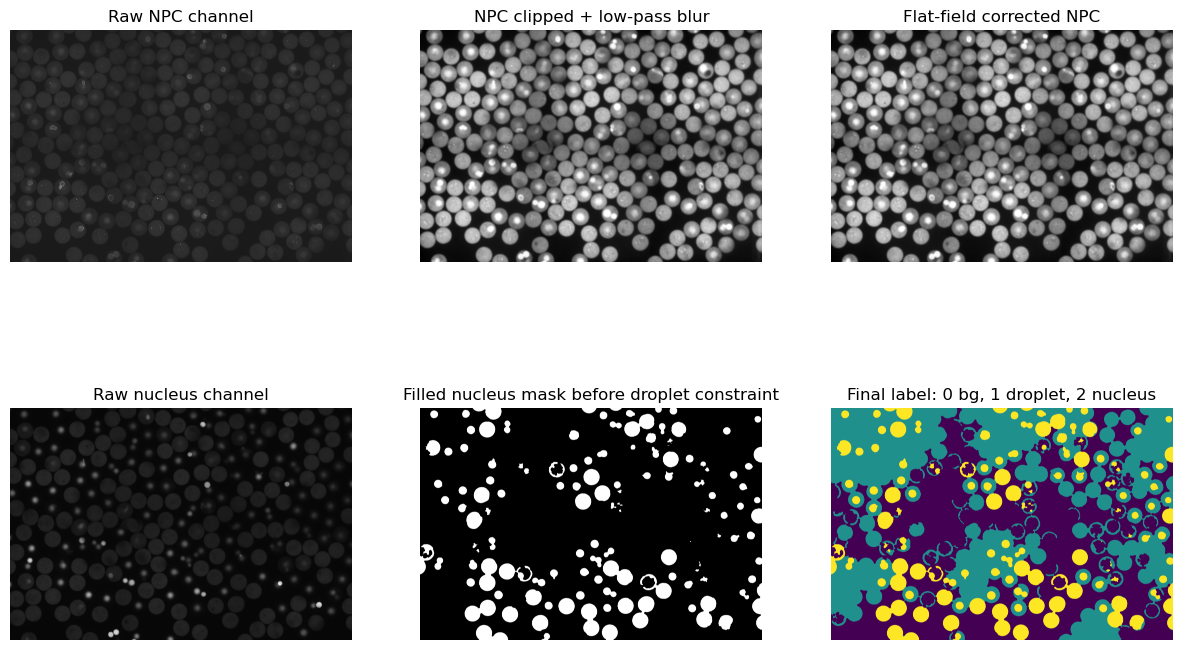

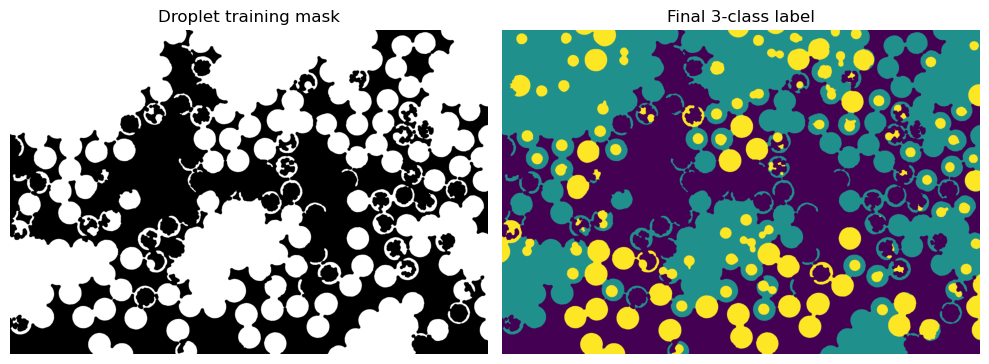

In [8]:
# ============================================================
# 8. QC: build and visualize one training plane
# ============================================================

t = 9 if img_fov.shape[0] > 9 else img_fov.shape[0] - 1
z = min(10, img_fov.shape[1] - 1)

npc2d = img_fov[t, z, NPC_CH, :, :]
nuc2d = img_fov[t, z, NUC_CH, :, :]

label_test, metadata_test, debug_test = build_training_label_plane(
    npc2d=npc2d, nuc2d=nuc2d, pixel_size_um=PIXEL_SIZE_UM,
    droplet_kwargs={
        "use_data_driven_tail":    cfg.use_data_driven_tail,
        "histogram_bins":          cfg.histogram_bins,
        "histogram_smooth_window": cfg.histogram_smooth_window,
        "tail_start_quantile":     cfg.tail_start_quantile,
        "min_clip_quantile":       cfg.min_clip_quantile,
        "max_clip_quantile":       cfg.max_clip_quantile,
        "blur_sigma":              cfg.droplet_blur_sigma,
        "local_block_size":        cfg.droplet_local_block_size,
        "local_offset":            cfg.droplet_local_offset,
        "min_droplet_area_um2":    cfg.min_droplet_area_um2,
        "hole_area_um2":           cfg.droplet_hole_area_um2,
        "closing_radius_um":       cfg.droplet_closing_radius_um,
    },
    nucleus_kwargs={
        "min_nucleus_area_um2":    cfg.min_nucleus_area_um2,
        "max_nucleus_area_um2":    cfg.max_nucleus_area_um2,
        "blur_sigma":              cfg.nucleus_blur_sigma,
        "threshold_method":        cfg.nucleus_threshold_method,
        "closing_radius_um":       cfg.nucleus_closing_radius_um,
        "hole_area_um2":           cfg.nucleus_hole_area_um2,
    },
)

print(metadata_test)
if label_test is not None:
    print("Label classes/counts:", dict(zip(*np.unique(label_test, return_counts=True))))

    fig, ax = plt.subplots(2, 3, figsize=(15, 9))
    ax[0, 0].imshow(npc2d, cmap="gray");        ax[0, 0].set_title("Raw NPC channel")
    ax[0, 1].imshow(debug_test["npc_blur"], cmap="gray"); ax[0, 1].set_title("NPC clipped + low-pass blur")
    # Flat-field proxy: show normalized npc_field
    ax[0, 2].imshow(debug_test["npc_field"], cmap="gray"); ax[0, 2].set_title("Flat-field corrected NPC")
    ax[1, 0].imshow(nuc2d, cmap="gray");        ax[1, 0].set_title("Raw nucleus channel")
    ax[1, 1].imshow(debug_test["nucleus_mask"], cmap="gray"); ax[1, 1].set_title("Filled nucleus mask before droplet constraint")
    ax[1, 2].imshow(label_test, cmap="viridis", vmin=0, vmax=2); ax[1, 2].set_title("Final label: 0 bg, 1 droplet, 2 nucleus")

    # Add droplet mask panel separately for reference
    fig2, ax2 = plt.subplots(1, 2, figsize=(10, 5))
    ax2[0].imshow(debug_test["droplet_mask"], cmap="gray"); ax2[0].set_title("Droplet training mask")
    ax2[1].imshow(label_test, cmap="viridis", vmin=0, vmax=2); ax2[1].set_title("Final 3-class label")
    for a in list(ax.ravel()) + list(ax2.ravel()):
        a.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Plane excluded:", metadata_test)


In [9]:
# ============================================================
# 9. Patch extraction helpers
# ============================================================

def build_input_patch(mem_patch, nuc_patch, npc_patch):
    """Returns H×W×3 float32 in [0,1]. Channel order: nucleus, NPC, membrane."""
    return np.stack([
        normalize_channel(nuc_patch),
        normalize_channel(npc_patch),
        normalize_channel(mem_patch),
    ], axis=-1).astype("float32")

def clamp_patch_center(cy, cx, height, width, patch_size):
    half = patch_size // 2
    cy = int(np.clip(cy, half, height - half))
    cx = int(np.clip(cx, half, width - half))
    return cy, cx

def extract_2d_patch(arr2d, cy, cx, patch_size):
    half = patch_size // 2
    return arr2d[cy - half:cy + half, cx - half:cx + half]

def extract_plane_patch(img_fov, t, z, cy, cx, patch_size=cfg.patch_size):
    mem_patch = extract_2d_patch(img_fov[t, z, MEM_CH], cy, cx, patch_size)
    nuc_patch = extract_2d_patch(img_fov[t, z, NUC_CH], cy, cx, patch_size)
    npc_patch = extract_2d_patch(img_fov[t, z, NPC_CH], cy, cx, patch_size)
    return build_input_patch(mem_patch, nuc_patch, npc_patch)

def centers_from_mask(mask, max_centers=None, rng=None):
    rng = rng or np.random.default_rng(SEED)
    labeled = measure.label(mask)
    centers = [(int(r.centroid[0]), int(r.centroid[1])) for r in measure.regionprops(labeled)]
    if max_centers is not None and len(centers) > max_centers:
        idx = rng.choice(len(centers), size=max_centers, replace=False)
        centers = [centers[i] for i in idx]
    return centers

def jitter_center(cy, cx, jitter_px, height, width, patch_size, rng):
    if jitter_px and jitter_px > 0:
        cy += int(rng.integers(-jitter_px, jitter_px + 1))
        cx += int(rng.integers(-jitter_px, jitter_px + 1))
    return clamp_patch_center(cy, cx, height, width, patch_size)

def random_centers_from_mask(mask, n, height, width, patch_size, rng):
    ys, xs = np.where(mask)
    if len(ys) == 0 or n <= 0:
        return []
    idx = rng.choice(len(ys), size=min(n, len(ys)), replace=False)
    return [clamp_patch_center(int(ys[i]), int(xs[i]), height, width, patch_size) for i in idx]

def generate_patch_centers(label, debug, patch_size=cfg.patch_size,
                            patches_per_plane=cfg.patches_per_plane,
                            jitter_px=cfg.patch_jitter_px, rng=None):
    rng = rng or np.random.default_rng(SEED)
    height, width = label.shape
    n_nucleus = int(round(patches_per_plane * cfg.nucleus_patch_fraction))
    n_droplet  = int(round(patches_per_plane * cfg.droplet_patch_fraction))
    n_hard     = max(0, patches_per_plane - n_nucleus - n_droplet)
    centers = []

    nuc_centers = centers_from_mask(debug["nucleus_mask"], rng=rng)
    if len(nuc_centers) > 0:
        take = min(n_nucleus, len(nuc_centers))
        idx = rng.choice(len(nuc_centers), size=take, replace=False)
        for i in idx:
            cy, cx = nuc_centers[i]
            centers.append(jitter_center(cy, cx, jitter_px, height, width, patch_size, rng))

    droplet_only = debug["droplet_mask"] & ~debug["nucleus_mask"]
    centers.extend(random_centers_from_mask(droplet_only, n_droplet, height, width, patch_size, rng))

    background = label == 0
    centers.extend(random_centers_from_mask(background, n_hard, height, width, patch_size, rng))

    half = patch_size // 2
    while len(centers) < patches_per_plane:
        cy = int(rng.integers(half, height - half))
        cx = int(rng.integers(half, width - half))
        centers.append((cy, cx))

    return centers[:patches_per_plane]


In [ ]:
# ============================================================
# 10. Build training patches from memory-mapped hyperstack
# ============================================================

def build_training_patches_from_hyperstack(img_fov, cfg=cfg, overwrite=False):
    if overwrite:
        for d in [cfg.image_patch_dir, cfg.label_patch_dir]:
            if d.exists():
                shutil.rmtree(d)
            d.mkdir(parents=True, exist_ok=True)

    n_t, n_z, n_c, height, width = img_fov.shape
    rng = np.random.default_rng(cfg.seed)   # FIX 3: uses cfg.seed
    patch_id = 0
    plane_rows = []

    for t in tqdm(range(n_t), desc="Timepoints"):
        for z in range(n_z):
            if cfg.exclude_edge_z_planes and not z_plane_allowed(z, n_z, cfg.edge_z_exclusion):
                plane_rows.append({"t": t, "z": z, "included": False,
                                   "reason": "edge_z_excluded", "patches_saved": 0})
                continue

            npc2d = img_fov[t, z, cfg.npc_channel_idx]
            nuc2d = img_fov[t, z, cfg.nucleus_channel_idx]

            label, metadata, debug = build_training_label_plane(
                npc2d=npc2d, nuc2d=nuc2d, pixel_size_um=cfg.pixel_size_um,
                min_focus_score=cfg.min_focus_score,
                use_focus_filter=cfg.use_focus_filter,
                droplet_kwargs={
                    "use_data_driven_tail":    cfg.use_data_driven_tail,
                    "histogram_bins":          cfg.histogram_bins,
                    "histogram_smooth_window": cfg.histogram_smooth_window,
                    "tail_start_quantile":     cfg.tail_start_quantile,
                    "min_clip_quantile":       cfg.min_clip_quantile,
                    "max_clip_quantile":       cfg.max_clip_quantile,
                    "blur_sigma":              cfg.droplet_blur_sigma,
                    "local_block_size":        cfg.droplet_local_block_size,
                    "local_offset":            cfg.droplet_local_offset,
                    "min_droplet_area_um2":    cfg.min_droplet_area_um2,
                    "hole_area_um2":           cfg.droplet_hole_area_um2,
                    "closing_radius_um":       cfg.droplet_closing_radius_um,
                },
                nucleus_kwargs={
                    "min_nucleus_area_um2":    cfg.min_nucleus_area_um2,
                    "max_nucleus_area_um2":    cfg.max_nucleus_area_um2,
                    "blur_sigma":              cfg.nucleus_blur_sigma,
                    "threshold_method":        cfg.nucleus_threshold_method,
                    "closing_radius_um":       cfg.nucleus_closing_radius_um,
                    "hole_area_um2":           cfg.nucleus_hole_area_um2,
                },
            )

            if label is None:
                plane_rows.append({
                    "t": t, "z": z, "included": False,
                    "reason": metadata.get("reason", "excluded"),
                    "focus_score": metadata.get("focus_score", np.nan),
                    "patches_saved": 0,
                })
                continue

            centers = generate_patch_centers(
                label, debug,
                patch_size=cfg.patch_size,
                patches_per_plane=cfg.patches_per_plane,
                jitter_px=cfg.patch_jitter_px, rng=rng,
            )

            patches_saved = 0
            for cy, cx in centers:
                y_patch = extract_2d_patch(label, cy, cx, cfg.patch_size)
                if y_patch.shape != (cfg.patch_size, cfg.patch_size):
                    continue
                if np.mean(y_patch > 0) < cfg.min_label_fraction:
                    continue
                x_patch = extract_plane_patch(img_fov, t, z, cy, cx, cfg.patch_size)

                stem = f"t{t:03d}_z{z:03d}_y{cy:04d}_x{cx:04d}_p{patch_id:06d}"
                np.save(cfg.image_patch_dir / f"img_{stem}.npy", x_patch.astype("float32"))
                np.save(cfg.label_patch_dir / f"lab_{stem}.npy", y_patch.astype("uint8"))
                patch_id += 1
                patches_saved += 1

            plane_rows.append({
                "t": t, "z": z, "included": True,
                "reason": metadata.get("reason", "included"),
                "focus_score":       metadata.get("focus_score", np.nan),
                "droplet_area_px":   metadata.get("droplet_area_px", np.nan),
                "nucleus_area_px":   metadata.get("nucleus_area_px", np.nan),
                "npc_clip_quantile": metadata.get("npc_clip_quantile", np.nan),
                "patches_saved":     patches_saved,
            })
            del label, debug
            gc.collect()

    summary_df = pd.DataFrame(plane_rows)
    summary_path = cfg.training_root / "training_patch_summary.csv"
    summary_df.to_csv(summary_path, index=False)
    print("Saved patches:", patch_id)
    print("Summary:", summary_path)
    return summary_df

# Uncomment when ready to generate patches.
summary_df = build_training_patches_from_hyperstack(img_fov, cfg=cfg, overwrite=False)


Timepoints:  30%|███       | 3/10 [53:35<2:10:12, 1116.10s/it]

In [ ]:
# ============================================================
# 11. Patch QC helpers
# ============================================================

def list_patch_files(cfg=cfg):
    img_paths = sorted(cfg.image_patch_dir.glob("*.npy"))
    lab_paths = sorted(cfg.label_patch_dir.glob("*.npy"))
    print(f"Found {len(img_paths)} image patches and {len(lab_paths)} label patches.")
    return img_paths, lab_paths


def show_random_patch(cfg=cfg, seed=SEED):
    img_paths, lab_paths = list_patch_files(cfg)
    if not img_paths:
        print("No patches found. Run build_training_patches_from_hyperstack first.")
        return
    rng = np.random.default_rng(seed)
    i = int(rng.integers(0, len(img_paths)))
    x = np.load(img_paths[i])
    y = np.load(lab_paths[i])
    fig, ax = plt.subplots(1, 4, figsize=(16, 4))
    ax[0].imshow(x[..., 0], cmap="gray");              ax[0].set_title("Input ch0: nucleus")
    ax[1].imshow(x[..., 1], cmap="gray");              ax[1].set_title("Input ch1: NPC")
    ax[2].imshow(x[..., 2], cmap="gray");              ax[2].set_title("Input ch2: membrane/context")
    ax[3].imshow(y, cmap="viridis", vmin=0, vmax=2);  ax[3].set_title("Label")
    for a in ax:
        a.axis("off")
    plt.tight_layout()
    plt.show()
    print(img_paths[i].name)
    print("Class counts:", dict(zip(*np.unique(y, return_counts=True))))

# Example after patch generation:
show_random_patch(cfg)


In [ ]:
# ============================================================
# 12. TensorFlow dataset — timepoint-stratified validation split
# ============================================================

def load_npy_pair_py(img_path, lab_path):
    for p in [img_path, lab_path]:
        if isinstance(p, np.ndarray):
            p = p.item()
        if isinstance(p, bytes):
            p = p.decode("utf-8")
    img_path = img_path.item() if isinstance(img_path, np.ndarray) else img_path
    lab_path = lab_path.item() if isinstance(lab_path, np.ndarray) else lab_path
    if isinstance(img_path, bytes):
        img_path = img_path.decode("utf-8")
    if isinstance(lab_path, bytes):
        lab_path = lab_path.decode("utf-8")
    img_arr = np.load(img_path).astype("float32")
    lab_arr = np.load(lab_path).astype("int32")
    return img_arr, lab_arr


def tf_load_npy_pair(img_path, lab_path):
    img_arr, lab_arr = tf.numpy_function(
        load_npy_pair_py, [img_path, lab_path], [tf.float32, tf.int32])
    img_arr.set_shape((cfg.patch_size, cfg.patch_size, cfg.n_channels))
    lab_arr.set_shape((cfg.patch_size, cfg.patch_size))
    lab_oh = tf.one_hot(lab_arr, depth=cfg.num_classes, dtype=tf.float32)
    return img_arr, lab_oh


def make_dataset(img_paths, lab_paths, batch_size=cfg.batch_size, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices(
        (list(map(str, img_paths)), list(map(str, lab_paths))))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(img_paths), seed=cfg.seed, reshuffle_each_iteration=True)
    ds = ds.map(tf_load_npy_pair, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


def build_train_val_datasets(cfg=cfg):
    """
    FIX 4: Timepoint-stratified validation split.

    Holds out cfg.val_timepoints entirely from training.
    If cfg.val_timepoints is None, the last timepoint is held out automatically.
    This prevents train/val patches from the same T/Z plane inflating val metrics.
    """
    img_paths, lab_paths = list_patch_files(cfg)
    if len(img_paths) != len(lab_paths):
        raise ValueError(f"Image/label count mismatch: {len(img_paths)} vs {len(lab_paths)}")
    if len(img_paths) == 0:
        raise ValueError("No patches found. Generate patches first.")

    # Resolve which timepoints go to validation
    if cfg.val_timepoints is None:
        n_t = img_fov.shape[0]
        val_timepoints = [n_t - 1]
    else:
        val_timepoints = list(cfg.val_timepoints)

    val_t_strs = [f"_t{t:03d}_" for t in val_timepoints]
    print(f"Validation timepoints: {val_timepoints}  →  patterns: {val_t_strs}")

    train_img, train_lab, val_img, val_lab = [], [], [], []
    for ip, lp in zip(img_paths, lab_paths):
        if any(s in ip.name for s in val_t_strs):
            val_img.append(ip)
            val_lab.append(lp)
        else:
            train_img.append(ip)
            train_lab.append(lp)

    if len(val_img) == 0:
        raise ValueError(
            f"No patches matched val_timepoints={val_timepoints}. "
            "Check that patches were generated from those timepoints.")

    print(f"Train patches : {len(train_img)}")
    print(f"Val patches   : {len(val_img)}")

    train_ds = make_dataset(train_img, train_lab, cfg.batch_size, shuffle=True)
    val_ds   = make_dataset(val_img,   val_lab,   cfg.batch_size, shuffle=False)
    return train_ds, val_ds, train_img, val_img

# Uncomment after patches are generated:
train_ds, val_ds, train_img_paths, val_img_paths = build_train_val_datasets(cfg)


In [ ]:
# ============================================================
# 13. U-Net model — v6.3 adds SpatialDropout2D
# ============================================================

def conv_block(x, filters, dropout_rate=0.0):
    """
    Conv → BN → ReLU → Conv → BN → ReLU  [→ SpatialDropout2D]

    SpatialDropout2D drops entire feature maps rather than individual pixels.
    This is more effective than standard Dropout for spatial feature learning
    and helps generalization when training data diversity is limited.
    """
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    if dropout_rate > 0.0:
        x = layers.SpatialDropout2D(dropout_rate)(x)
    return x


def encoder_block(x, filters, dropout_rate=0.0):
    c = conv_block(x, filters, dropout_rate=dropout_rate)
    p = layers.MaxPooling2D((2, 2))(c)
    return c, p


def decoder_block(x, skip, filters, dropout_rate=0.0):
    x = layers.Conv2DTranspose(filters, 2, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters, dropout_rate=dropout_rate)
    return x


def build_unet(input_shape=None, num_classes=None):
    if input_shape is None:
        input_shape = (cfg.patch_size, cfg.patch_size, cfg.n_channels)
    if num_classes is None:
        num_classes = cfg.num_classes

    inputs = layers.Input(shape=input_shape)

    # Encoder — no dropout in shallow layers (preserve low-level spatial features)
    c1, p1 = encoder_block(inputs, 32,  dropout_rate=0.0)
    c2, p2 = encoder_block(p1,     64,  dropout_rate=0.0)
    c3, p3 = encoder_block(p2,     128, dropout_rate=0.0)
    c4, p4 = encoder_block(p3,     256, dropout_rate=0.0)

    # Bottleneck — highest dropout: most abstract, most prone to memorization
    bn = conv_block(p4, 512, dropout_rate=0.5)

    # Decoder — dropout in the two deepest blocks only
    d1 = decoder_block(bn, c4, 256, dropout_rate=0.3)
    d2 = decoder_block(d1, c3, 128, dropout_rate=0.3)
    d3 = decoder_block(d2, c2, 64,  dropout_rate=0.0)
    d4 = decoder_block(d3, c1, 32,  dropout_rate=0.0)

    outputs = layers.Conv2D(num_classes, 1, activation="softmax")(d4)
    return models.Model(inputs, outputs, name=cfg.model_name)


model = build_unet()
model.summary()


In [ ]:
# ============================================================
# 14. Loss, metrics, callbacks, training
# ============================================================

# FIX 1 & 2: Weighted CE + weighted Dice loss
# Class weights: [bg=0.5, droplet=1.0, nucleus=4.0]
# Background dominates pixel area → down-weight it.
# Nucleus is rare and the hardest class → up-weight it 4×.
# These are starting values — adjust after inspecting per-class Dice in training logs.

_CLASS_WEIGHTS = tf.constant(list(cfg.loss_class_weights), dtype=tf.float32)


def weighted_dice_loss(y_true, y_pred, smooth=1e-6):
    """
    Per-class Dice, weighted so nucleus contributes more to the total loss.
    Averaging equally across classes (as in v6.2) allowed high background/droplet
    Dice to mask poor nucleus Dice.
    """
    y_true_f = tf.reshape(y_true, [-1, cfg.num_classes])
    y_pred_f = tf.reshape(y_pred, [-1, cfg.num_classes])
    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=0)   # (num_classes,)
    denom        = tf.reduce_sum(y_true_f + y_pred_f, axis=0)
    dice_per_class = (2.0 * intersection + smooth) / (denom + smooth)
    weighted_mean  = (
        tf.reduce_sum(_CLASS_WEIGHTS * dice_per_class) /
        tf.reduce_sum(_CLASS_WEIGHTS)
    )
    return 1.0 - weighted_mean


def weighted_ce_loss(y_true, y_pred):
    """
    Categorical cross-entropy where each pixel's loss is scaled by its class weight.
    Pixels in the nucleus class contribute 4× more than background pixels.
    """
    pixel_weights = tf.reduce_sum(_CLASS_WEIGHTS * y_true, axis=-1)   # (B, H, W)
    ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)      # (B, H, W)
    return tf.reduce_mean(pixel_weights * ce)


def combined_weighted_loss(y_true, y_pred):
    """Primary training loss: weighted CE + weighted Dice."""
    return weighted_ce_loss(y_true, y_pred) + weighted_dice_loss(y_true, y_pred)


# ── Metrics ───────────────────────────────────────────────────────────────────
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """Unweighted mean Dice — kept as a monitoring metric for comparison with v6.2."""
    y_true_f = tf.reshape(y_true, [-1, cfg.num_classes])
    y_pred_f = tf.reshape(y_pred, [-1, cfg.num_classes])
    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=0)
    denom        = tf.reduce_sum(y_true_f + y_pred_f, axis=0)
    return tf.reduce_mean((2.0 * intersection + smooth) / (denom + smooth))


def nucleus_dice(y_true, y_pred, smooth=1e-6):
    """Dice for nucleus class only — the primary diagnostic metric."""
    y_true_nuc = y_true[..., 2]
    y_pred_nuc = y_pred[..., 2]
    intersection = tf.reduce_sum(y_true_nuc * y_pred_nuc)
    denom        = tf.reduce_sum(y_true_nuc) + tf.reduce_sum(y_pred_nuc)
    return (2.0 * intersection + smooth) / (denom + smooth)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=cfg.learning_rate),
    loss=combined_weighted_loss,
    metrics=[dice_coefficient, nucleus_dice, "categorical_accuracy"],
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(cfg.best_model_path),
        monitor="val_nucleus_dice",   # monitor nucleus Dice, not total val_loss
        save_best_only=True,
        mode="max",
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_nucleus_dice",
        factor=0.5,
        patience=4,
        min_delta=1e-4,
        mode="max",
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_nucleus_dice",
        patience=10,
        restore_best_weights=True,
        mode="max",
        verbose=1,
    ),
]

# Uncomment after train_ds and val_ds are created:
history = model.fit(train_ds, validation_data=val_ds, epochs=cfg.epochs, callbacks=callbacks)
model.save(cfg.final_model_path)


In [ ]:
# ============================================================
# 15. Training history visualization
# ============================================================

def plot_training_history(history):
    """
    Plot loss, mean Dice, nucleus-only Dice, and accuracy.
    Nucleus Dice is the key diagnostic — it should rise more steeply in v6.3
    than v6.2 due to weighted loss.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss
    axes[0].plot(history.history["loss"],     label="Train loss")
    axes[0].plot(history.history["val_loss"], label="Val loss")
    axes[0].set_title("Combined weighted loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    # Mean Dice vs nucleus Dice
    axes[1].plot(history.history["dice_coefficient"],     label="Train mean Dice")
    axes[1].plot(history.history["val_dice_coefficient"], label="Val mean Dice")
    axes[1].plot(history.history["nucleus_dice"],         label="Train nucleus Dice", linestyle="--")
    axes[1].plot(history.history["val_nucleus_dice"],     label="Val nucleus Dice",   linestyle="--")
    axes[1].set_title("Dice metrics (nucleus Dice = primary target)")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    # Accuracy
    axes[2].plot(history.history["categorical_accuracy"],     label="Train accuracy")
    axes[2].plot(history.history["val_categorical_accuracy"], label="Val accuracy")
    axes[2].set_title("Categorical accuracy")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

# After training:
plot_training_history(history)


In [ ]:
# ============================================================
# 16. Visualize validation predictions
# ============================================================

def show_prediction_batch(model, dataset, n=2):
    for x_batch, y_batch in dataset.take(1):
        preds = model.predict(x_batch)
        pred_labels = np.argmax(preds, axis=-1)
        true_labels = np.argmax(y_batch.numpy(), axis=-1)
        n_show = min(n, x_batch.shape[0])

        for i in range(n_show):
            fig, axes = plt.subplots(2, 4, figsize=(20, 10))

            # Top row: inputs + labels
            axes[0, 0].imshow(x_batch[i, ..., 0], cmap="gray"); axes[0, 0].set_title("Input: nucleus")
            axes[0, 1].imshow(x_batch[i, ..., 1], cmap="gray"); axes[0, 1].set_title("Input: NPC")
            axes[0, 2].imshow(true_labels[i],  cmap="viridis", vmin=0, vmax=2); axes[0, 2].set_title("True label")
            axes[0, 3].imshow(pred_labels[i],  cmap="viridis", vmin=0, vmax=2); axes[0, 3].set_title("Predicted label")

            # Bottom row: per-class probability maps
            axes[1, 0].imshow(preds[i, ..., 0], cmap="inferno", vmin=0, vmax=1); axes[1, 0].set_title("Background prob")
            axes[1, 1].imshow(preds[i, ..., 1], cmap="inferno", vmin=0, vmax=1); axes[1, 1].set_title("Droplet prob")
            axes[1, 2].imshow(preds[i, ..., 2], cmap="inferno", vmin=0, vmax=1); axes[1, 2].set_title("Nucleus prob")

            # Difference map: highlight where nucleus is missed or confused with droplet
            nuc_true = (true_labels[i] == 2).astype(float)
            nuc_pred = (pred_labels[i] == 2).astype(float)
            diff = nuc_true - nuc_pred   # +1 = missed nucleus, -1 = false positive
            axes[1, 3].imshow(diff, cmap="RdBu", vmin=-1, vmax=1); axes[1, 3].set_title("Nucleus diff (true − pred)")

            for a in axes.ravel():
                a.axis("off")
            plt.tight_layout()
            plt.show()
        break

# After training:
show_prediction_batch(model, val_ds, n=2)
